📥 Loading datasets...
 Combined dataset shape: (10000, 327)
 Class distribution:
label
0    7000
1     614
2     597
3     579
4     601
5     609
Name: count, dtype: int64

🔬 Dataset split:
  Test set (hold-out): 2500 samples
  Pool for Active Learning: 7500 samples

🌱 Initial seed: 375 samples (5.0%)
🔁 Query size per iteration: 100
🔄 Max iterations: 15

=== Iteration 1 ===
  Labeled samples: 375
  Test Accuracy: 0.9468
  Test Macro-F1: 0.8524

=== Iteration 2 ===
  Labeled samples: 475
  Test Accuracy: 0.9440
  Test Macro-F1: 0.8411

=== Iteration 3 ===
  Labeled samples: 575
  Test Accuracy: 0.9420
  Test Macro-F1: 0.8410

=== Iteration 4 ===
  Labeled samples: 675
  Test Accuracy: 0.9452
  Test Macro-F1: 0.8492

=== Iteration 5 ===
  Labeled samples: 775
  Test Accuracy: 0.9436
  Test Macro-F1: 0.8451

=== Iteration 6 ===
  Labeled samples: 875
  Test Accuracy: 0.9544
  Test Macro-F1: 0.8748

=== Iteration 7 ===
  Labeled samples: 975
  Test Accuracy: 0.9512
  Test Macro-F1: 0.8660

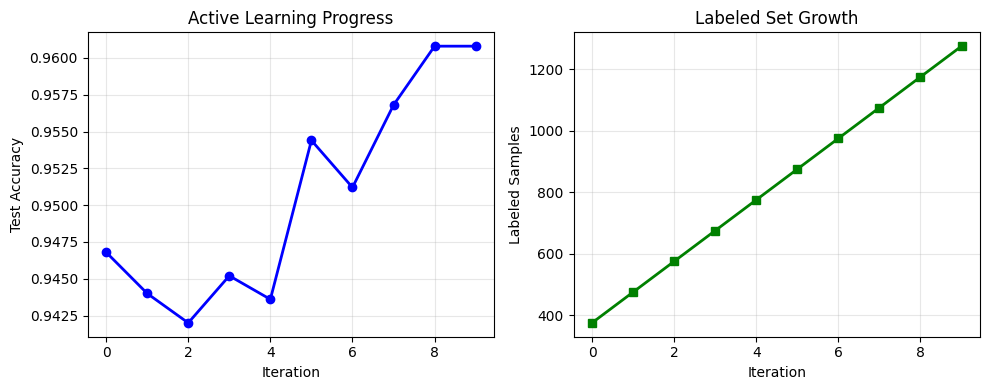


🎉 Active Learning complete!


In [1]:
# ========================================================
# IMPROVED Active Learning based FL Poisoning Attack Detector
# ========================================================

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit

from sklearn.svm import SVC
# --------------------------------------------------------
# 1. Load datasets
# --------------------------------------------------------
print("📥 Loading datasets...")

df_mnist = pd.read_csv("finaltrial_mnist.csv")
df_cifar = pd.read_csv("3finaltrial_cifar10.csv")

df_mnist["dataset_source"] = "mnist"
df_cifar["dataset_source"] = "cifar"

df = pd.concat([df_mnist, df_cifar], ignore_index=True)
df = df.sample(frac=1.0, random_state=42).reset_index(drop=True)

print(f" Combined dataset shape: {df.shape}")
print(f" Class distribution:\n{df['label'].value_counts().sort_index()}")

# --------------------------------------------------------
# 2. Feature selection
# --------------------------------------------------------
pure_numeric_features = [col for col in df.columns if col.startswith("dct_")]

categorical_features = [
    "attack_variant",
    "client_classes",
    "dataset_source"
]

FEATURES = pure_numeric_features + categorical_features
TARGET = "label"

X = df[FEATURES]
y = df[TARGET].astype(int)

# --------------------------------------------------------
# 3. Create PROPER train/test split
# --------------------------------------------------------
X_pool, X_test, y_pool, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y  # Maintain class distribution
)

print(f"\n🔬 Dataset split:")
print(f"  Test set (hold-out): {len(X_test)} samples")
print(f"  Pool for Active Learning: {len(X_pool)} samples")

# --------------------------------------------------------
# 4. Pipeline builder
# --------------------------------------------------------
def build_pipeline():
    from sklearn.compose import ColumnTransformer
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.pipeline import Pipeline

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), pure_numeric_features),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ]
    )

    clf =  SVC(
        kernel="rbf",
        C=10,
        gamma="scale",
        class_weight="balanced",
        probability=True,
        random_state=42
    )

    return Pipeline([
        ("preprocess", preprocessor),
        ("clf", clf)
    ])

# --------------------------------------------------------
# 5. Active Learning with proper seed
# --------------------------------------------------------
def active_learning_train(
    X_pool,
    y_pool,
    X_test,
    y_test,
    seed_frac=0.05,
    query_size=100,
    max_iters=20
):
    """Active learning with entropy sampling and proper evaluation"""

    # Create stratified initial seed
    strat_key = y_pool.astype(str) + "_" + X_pool["dataset_source"]
    sss = StratifiedShuffleSplit(
        n_splits=1, test_size=seed_frac, random_state=42
    )

    for _, seed_idx in sss.split(X_pool, y_pool):
        labeled_idx = set(seed_idx.tolist())

    unlabeled_idx = set(range(len(X_pool))) - labeled_idx

    model = build_pipeline()

    # Performance tracking
    history = {
        'iterations': [],
        'labeled_samples': [],
        'test_accuracy': [],
        'test_f1': []
    }

    print(f"\n🌱 Initial seed: {len(labeled_idx)} samples ({seed_frac*100:.1f}%)")
    print(f"🔁 Query size per iteration: {query_size}")
    print(f"🔄 Max iterations: {max_iters}")

    for iteration in range(max_iters):
        # Train on current labeled set
        train_idx = list(labeled_idx)
        model.fit(X_pool.iloc[train_idx], y_pool.iloc[train_idx])

        # Evaluate on test set
        from sklearn.metrics import accuracy_score, f1_score
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')

        # Store performance
        history['iterations'].append(iteration)
        history['labeled_samples'].append(len(labeled_idx))
        history['test_accuracy'].append(acc)
        history['test_f1'].append(f1)

        print(f"\n=== Iteration {iteration + 1} ===")
        print(f"  Labeled samples: {len(labeled_idx)}")
        print(f"  Test Accuracy: {acc:.4f}")
        print(f"  Test Macro-F1: {f1:.4f}")

        # Stop if pool exhausted
        if len(unlabeled_idx) == 0:
            print("  Pool exhausted!")
            break

        # Select most uncertain samples from pool
        pool_idx = list(unlabeled_idx)
        probs = model.predict_proba(X_pool.iloc[pool_idx])

        # Calculate entropy
        epsilon = 1e-12
        entropies = -np.sum(probs * np.log(probs + epsilon), axis=1)

        # Get indices of highest entropy samples
        actual_query = min(query_size, len(unlabeled_idx))
        query_ids = np.argsort(entropies)[-actual_query:]

        # Convert to original indices
        new_samples = [pool_idx[i] for i in query_ids]

        # Update sets
        labeled_idx.update(new_samples)
        unlabeled_idx.difference_update(new_samples)

        # Check for convergence
        if iteration > 5 and abs(history['test_accuracy'][-1] - history['test_accuracy'][-2]) < 0.001:
            print(f"  Convergence reached at iteration {iteration + 1}")
            break

    return model, labeled_idx, history

# --------------------------------------------------------
# 6. Run Active Learning
# --------------------------------------------------------
final_model, final_labeled_idx, history = active_learning_train(
    X_pool=X_pool,
    y_pool=y_pool,
    X_test=X_test,
    y_test=y_test,
    seed_frac=0.05,
    query_size=100,
    max_iters=15
)

# --------------------------------------------------------
# 7. Final Evaluation & Visualization
# --------------------------------------------------------
print("\n" + "="*50)
print("📊 FINAL RESULTS")
print("="*50)

# Final evaluation
from sklearn.metrics import classification_report, confusion_matrix

y_pred_final = final_model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

print(f"\nLabeling Efficiency:")
print(f"  Total pool samples: {len(X_pool)}")
print(f"  Final labeled samples: {len(final_labeled_idx)}")
print(f"  Efficiency: {len(final_labeled_idx)/len(X_pool)*100:.1f}%")

# --------------------------------------------------------
# 8. Save everything
# --------------------------------------------------------
model_bundle = {
    "model": final_model,
    "features": FEATURES,
    "history": history,
    "final_labeled_count": len(final_labeled_idx),
    "test_performance": classification_report(y_test, y_pred_final, output_dict=True)
}

joblib.dump(final_model, "active_svm.pkl")
print("\n✅ Saved: active_svm.pkl")

# --------------------------------------------------------
# 9. Plot learning curve
# --------------------------------------------------------
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history['iterations'], history['test_accuracy'], 'b-o', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Test Accuracy')
plt.title('Active Learning Progress')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['iterations'], history['labeled_samples'], 'g-s', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Labeled Samples')
plt.title('Labeled Set Growth')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('active_learning_progress.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🎉 Active Learning complete!")